# Análises das copas do mundo

Este notebook será usado para explorar resultados de jogos das copas do mundo.

Baixar dados do repositório https://github.com/jfjelstul/worldcup

Fluxo inicial:
1. baixar os dados de partidas;
2. selecionar as colunas mais úteis para análise;
3. salvar uma base local em CSV para reutilizar nas próximas etapas.

In [1]:
import pandas as pd

# URL do dataset específico de partidas (matches)
url = "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/matches.csv"

# Carregar os dados
df = pd.read_csv(url)

# O dataset inclui jogos masculinos e femininos.
# Em `matches` não há coluna de sexo; então o filtro é pelo nome do torneio.
df = df[df["tournament_name"].str.contains("Men's World Cup", na=False)].copy()

# Extrair o ano do torneio a partir de tournament_name (ex.: "1930 FIFA Men's World Cup")
df["ano"] = df["tournament_name"].str.extract(r"(\d{4})").astype("Int64")

# Selecionar apenas as colunas necessárias para análise de resultados
colunas_interesse = [
    "ano",
    "stage_name",
    "home_team_name",
    "away_team_name",
    "home_team_score",
    "away_team_score",
]
dados = df[colunas_interesse].rename(
    columns={
        "stage_name": "fase",
        "home_team_name": "time_casa",
        "away_team_name": "time_visitante",
        "home_team_score": "gols_casa",
        "away_team_score": "gols_visitante",
    }
)

# Salvar CSV local para uso nas próximas análises
arquivo_saida = "copas_1930_2022.csv"
dados.to_csv(arquivo_saida, index=False)

print(f"Arquivo gerado com sucesso: {arquivo_saida}")
print(f"Total de jogos masculinos: {len(dados)}")
display(dados.head())


Arquivo gerado com sucesso: copas_1930_2022.csv
Total de jogos masculinos: 964


,ano,fase,time_casa,time_visitante,gols_casa,gols_visitante
0,1930,group stage,France,Mexico,4,1
1,1930,group stage,United States,Belgium,3,0
2,1930,group stage,Yugoslavia,Brazil,2,1
3,1930,group stage,Romania,Peru,3,1
4,1930,group stage,Argentina,France,1,0


In [19]:
# Análise inicial
display(dados.info())
display(dados["fase"].value_counts())

<class 'pandas.DataFrame'>
Index: 964 entries, 0 to 1247
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ano             964 non-null    Int64
 1   fase            964 non-null    str  
 2   time_casa       964 non-null    str  
 3   time_visitante  964 non-null    str  
 4   gols_casa       964 non-null    int64
 5   gols_visitante  964 non-null    int64
dtypes: Int64(1), int64(2), str(3)
memory usage: 53.7 KB


None

fase
group stage           676
round of 16            97
quarter-finals         70
semi-finals            38
second group stage     36
final                  21
third-place match      20
final round             6
Name: count, dtype: int64

In [57]:
# analisar fases estranhas
display(dados[dados["fase"]=="second group stage"])
display(dados[dados["fase"]=="final round"])

,ano,fase,time_casa,time_visitante,gols_casa,gols_visitante,placar,total_gols
256,1974,second group stage,Yugoslavia,West Germany,0,2,2-0,2
257,1974,second group stage,Brazil,East Germany,1,0,1-0,1
258,1974,second group stage,Netherlands,Argentina,4,0,4-0,4
259,1974,second group stage,Sweden,Poland,0,1,1-0,1
260,1974,second group stage,Argentina,Brazil,1,2,2-1,3
261,1974,second group stage,East Germany,Netherlands,0,2,2-0,2
262,1974,second group stage,Poland,Yugoslavia,2,1,2-1,3
263,1974,second group stage,West Germany,Sweden,4,2,4-2,6
264,1974,second group stage,Poland,West Germany,0,1,1-0,1
265,1974,second group stage,Argentina,East Germany,1,1,1-1,2


,ano,fase,time_casa,time_visitante,gols_casa,gols_visitante,placar,total_gols
69,1950,final round,Brazil,Sweden,7,1,7-1,8
70,1950,final round,Uruguay,Spain,2,2,2-2,4
71,1950,final round,Brazil,Spain,6,1,6-1,7
72,1950,final round,Uruguay,Sweden,3,2,3-2,5
73,1950,final round,Sweden,Spain,3,1,3-1,4
74,1950,final round,Uruguay,Brazil,2,1,2-1,3


In [2]:
# ver distribuição de placares

# Criar coluna de placar com o maior número primeiro (X-Y)
maior_gols = dados[["gols_casa", "gols_visitante"]].max(axis=1)
menor_gols = dados[["gols_casa", "gols_visitante"]].min(axis=1)

dados["placar"] = maior_gols.astype(str) + "-" + menor_gols.astype(str)

# coluna de gols da partida
dados["total_gols"] = dados["gols_casa"] + dados["gols_visitante"]
#display(dados[["ano", "time_casa", "time_visitante", "gols_casa", "gols_visitante", "placar", "total_gols"]].head())

# fases eliminatórias
fases_ko = [
    "round of 16",
    "quarter-finals",
    "semi-finals",
    "final",
    "third-place match",
]

dados["KO"] = dados["fase"].isin(fases_ko)

# tabelas
freq = dados["placar"].value_counts()

tabela_placar = (
    freq.head(5)
    .rename("contagem")
    .to_frame()
    .assign(porcentagem=lambda x: (x["contagem"] / freq.sum()))
)

tabela_placar["porcentagem"] = tabela_placar["porcentagem"].map("{:.2%}".format)
display(tabela_placar)

print(f"Placares 7-1 e 10-1")
display(dados[(dados["placar"] == "7-1") | (dados["placar"] == "10-1") | (dados["placar"] == "7-5")])

placares_unicos = dados["placar"].value_counts()
display(placares_unicos[placares_unicos == 1])

,contagem,porcentagem
placar,,
1-0,182,18.88%
2-1,152,15.77%
2-0,111,11.51%
1-1,92,9.54%
0-0,78,8.09%


Placares 7-1 e 10-1


,ano,fase,time_casa,time_visitante,gols_casa,gols_visitante,placar,total_gols,KO
22,1934,round of 16,Italy,United States,7,1,7-1,8,True
69,1950,final round,Brazil,Sweden,7,1,7-1,8,False
93,1954,quarter-finals,Austria,Switzerland,7,5,7-5,12,True
312,1982,group stage,Hungary,El Salvador,10,1,10-1,11,False
1012,2014,semi-finals,Brazil,Germany,1,7,7-1,8,True


placar
6-5     1
8-3     1
7-2     1
7-5     1
7-3     1
5-3     1
10-1    1
6-2     1
Name: count, dtype: int64

In [3]:
# só fase de grupos
# não teve fase de grupos em 1934 e 1938
# freq = dados[dados["fase"] =="group stage"]["ano"].value_counts().sort_index()

# tabela_placar = (
#     freq.rename("contagem")
#     .to_frame()
#     .assign(porcentagem=lambda x: (x["contagem"] / freq.sum()))
# )

# tabela_placar["porcentagem"] = tabela_placar["porcentagem"].map("{:.2%}".format)
# print(f"Fase: group stage")
# display(tabela_placar)

freq = dados[dados["KO"] == False]["placar"].value_counts()

tabela_placar = (
    freq.head(5)
    .rename("contagem")
    .to_frame()
    .assign(porcentagem=lambda x: (x["contagem"] / freq.sum()))
)

tabela_placar["porcentagem"] = tabela_placar["porcentagem"].map("{:.2%}".format)
print(f"Fase: classificatória")
display(tabela_placar)

# mata mata
freq = dados[dados["KO"] == True]["placar"].value_counts()

tabela_placar = (
    freq.head(5)
    .rename("contagem")
    .to_frame()
    .assign(porcentagem=lambda x: (x["contagem"] / freq.sum()))
)

tabela_placar["porcentagem"] = tabela_placar["porcentagem"].map("{:.2%}".format)
print(f"Fase: eliminatórias")
display(tabela_placar)


Fase: classificatória


,contagem,porcentagem
placar,,
1-0,137,19.08%
2-1,105,14.62%
2-0,89,12.40%
1-1,72,10.03%
0-0,66,9.19%


Fase: eliminatórias


,contagem,porcentagem
placar,,
2-1,47,19.11%
1-0,45,18.29%
2-0,22,8.94%
1-1,20,8.13%
3-2,18,7.32%


In [71]:
#Comparar períodos
anobase = 1966

# primeiras copas
freq = dados[dados["ano"] <= anobase]["placar"].value_counts()

tabela_placar = (
    freq.head(5)
    .rename("contagem")
    .to_frame()
    .assign(porcentagem=lambda x: (x["contagem"] / freq.sum()))
)

tabela_placar["porcentagem"] = tabela_placar["porcentagem"].map("{:.2%}".format)
display(tabela_placar)

# últimas copas
freq = dados[dados["ano"] > anobase]["placar"].value_counts()

tabela_placar = (
    freq.head(5)
    .rename("contagem")
    .to_frame()
    .assign(porcentagem=lambda x: (x["contagem"] / freq.sum()))
)

tabela_placar["porcentagem"] = tabela_placar["porcentagem"].map("{:.2%}".format)
display(tabela_placar)

,contagem,porcentagem
placar,,
2-1,31,15.50%
3-1,23,11.50%
1-0,23,11.50%
2-0,20,10.00%
3-2,11,5.50%


,contagem,porcentagem
placar,,
1-0,159,20.81%
2-1,121,15.84%
2-0,91,11.91%
1-1,83,10.86%
0-0,69,9.03%


In [4]:
for ano, df_ano in dados.groupby("ano"):
    freq = df_ano["placar"].value_counts()

    tabela_placar = (
        freq.head(5)
        .rename("contagem")
        .to_frame()
        .assign(porcentagem=lambda x: (x["contagem"] / freq.sum()).map("{:.2%}".format))
    )

    media_gols = df_ano["total_gols"].mean()

    print(f"Ano {ano}")
    print(f"Média de gols por jogo: {media_gols:.2f}")
    display(tabela_placar)
    print()

Ano 1930
Média de gols por jogo: 3.89


,contagem,porcentagem
placar,,
1-0,4,22.22%
3-0,3,16.67%
4-0,3,16.67%
3-1,2,11.11%
6-1,2,11.11%



Ano 1934
Média de gols por jogo: 4.12


,contagem,porcentagem
placar,,
3-2,5,29.41%
2-1,4,23.53%
3-1,2,11.76%
1-0,2,11.76%
5-2,1,5.88%



Ano 1938
Média de gols por jogo: 4.67


...

,contagem,porcentagem
placar,,
2-1,15,23.44%
1-0,12,18.75%
0-0,7,10.94%
3-1,5,7.81%
3-0,5,7.81%



Ano 2018
Média de gols por jogo: 2.64


,contagem,porcentagem
placar,,
1-0,15,23.44%
2-1,14,21.88%
2-0,10,15.62%
1-1,7,10.94%
3-0,5,7.81%



Ano 2022
Média de gols por jogo: 2.69


,contagem,porcentagem
placar,,
2-0,12,18.75%
2-1,11,17.19%
1-0,10,15.62%
0-0,7,10.94%
1-1,5,7.81%


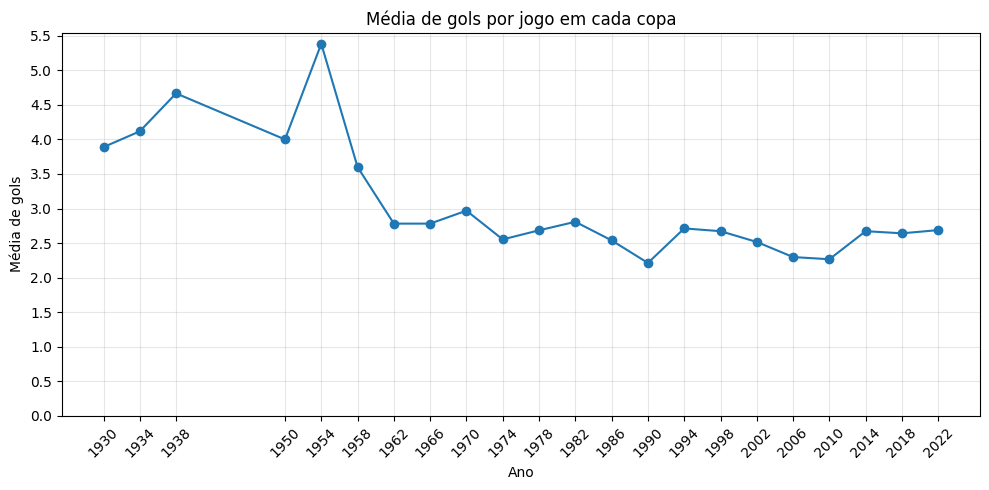

In [51]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# média de gols por jogo em cada copa (ano)
media_por_ano = (
    dados.groupby("ano", as_index=False)["total_gols"]
    .mean()
    .sort_values("ano")
)

# gráfico de linha
plt.figure(figsize=(10, 5))
plt.plot(media_por_ano["ano"], media_por_ano["total_gols"], marker="o")
plt.title("Média de gols por jogo em cada copa")
plt.xlabel("Ano")
plt.ylabel("Média de gols")
plt.grid(True, alpha=0.3)
plt.xticks(media_por_ano["ano"], rotation=45)
plt.ylim(bottom=0)

ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))

plt.tight_layout()
plt.show()

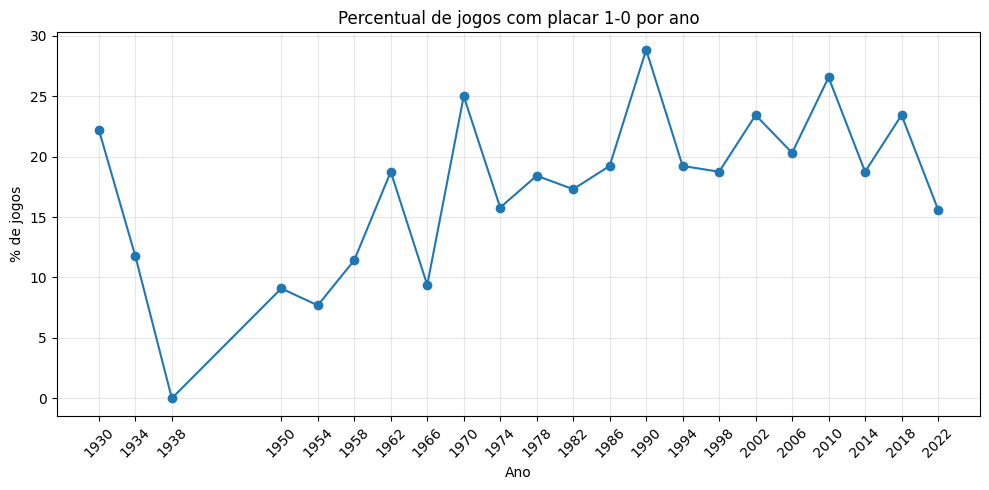

In [76]:
import matplotlib.pyplot as plt

# % de jogos com placar 1-0 em cada ano
pct_1_0_por_ano = (
    dados.assign(eh_1_0=dados["placar"].eq("1-0"))
    .groupby("ano", as_index=False)["eh_1_0"]
    .mean()
    .sort_values("ano")
)

# converter para porcentagem
pct_1_0_por_ano["pct_1_0"] = pct_1_0_por_ano["eh_1_0"] * 100

# gráfico de linha
plt.figure(figsize=(10, 5))
plt.plot(pct_1_0_por_ano["ano"], pct_1_0_por_ano["pct_1_0"], marker="o")
plt.title("Percentual de jogos com placar 1-0 por ano")
plt.xlabel("Ano")
plt.ylabel("% de jogos")
plt.grid(True, alpha=0.3)
plt.xticks(pct_1_0_por_ano["ano"], rotation=45)
plt.tight_layout()
plt.show()

In [72]:
# em 1938 não teve fase de grupos, já era eliminatória desde o início
display(dados[dados["ano"] == 1938])
freq = dados[dados["ano"] == 1938]["placar"].value_counts()

tabela_placar = (
    freq.head(5)
    .rename("contagem")
    .to_frame()
    .assign(porcentagem=lambda x: (x["contagem"] / freq.sum()))
)

tabela_placar["porcentagem"] = tabela_placar["porcentagem"].map("{:.2%}".format)
display(tabela_placar)

,ano,fase,time_casa,time_visitante,gols_casa,gols_visitante,placar,total_gols,KO
35,1938,round of 16,Switzerland,Germany,1,1,1-1,2,True
36,1938,round of 16,Cuba,Romania,3,3,3-3,6,True
37,1938,round of 16,France,Belgium,3,1,3-1,4,True
38,1938,round of 16,Hungary,Dutch East Indies,6,0,6-0,6,True
39,1938,round of 16,Italy,Norway,2,1,2-1,3,True
40,1938,round of 16,Brazil,Poland,6,5,6-5,11,True
41,1938,round of 16,Czechoslovakia,Netherlands,3,0,3-0,3,True
42,1938,round of 16,Cuba,Romania,2,1,2-1,3,True
43,1938,round of 16,Switzerland,Germany,4,2,4-2,6,True
44,1938,quarter-finals,Brazil,Czechoslovakia,1,1,1-1,2,True


,contagem,porcentagem
placar,,
2-1,4,22.22%
4-2,3,16.67%
1-1,2,11.11%
3-1,2,11.11%
3-3,1,5.56%
